# Sentence embedding clusters by IR section

This notebook compares one skill document with one deterministic BABILong 8k prompt. It calls Alexandria's `represent()` and works only with sentence embeddings stored in the resulting IR. HDBSCAN clusters the original normalized sentence embeddings; UMAP is used only to draw a two-dimensional view. In each view, color means the sentence's deepest containing IR section and marker shape means its HDBSCAN assignment.

In [1]:
import csv
import os
import sys
import textwrap
from collections import Counter
from importlib import import_module
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv
from hdbscan import HDBSCAN
from matplotlib.lines import Line2D
from sklearn.metrics import silhouette_samples
from umap import UMAP

from alexandria.ir.document import Document, Section, Sentence
from alexandria.ops.features.represent import represent


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src/alexandria").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from the Alexandria checkout.")


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))
load_cases = import_module("benchmarks.babilong_8k.cases").load_cases
load_dotenv(REPO_ROOT / ".env")
RANDOM_SEED = 42
print(f"repository: {REPO_ROOT.name}")

repository: alexandria-embedding-clusters


## Define semantic cohesion metrics

The analysis below excludes structural sentences that Alexandria marks non-optimizable, such as Markdown headers and XML tags. No single number proves cohesion, so four complementary measures are reported: leave-one-out cosine to the section centroid, mean pairwise cosine within the section, nearest-neighbor section purity above its prevalence-based chance rate, and mean cosine silhouette. Higher is more cohesive for every column, although silhouette can be negative. The leave-one-out calculation prevents each sentence from artificially increasing its own centroid similarity. Sections with very few sentences should be treated as descriptive only.

In [2]:
def section_cohesion(source: str, source_rows: list[dict[str, object]]) -> list[dict[str, object]]:
    eligible_rows = [row for row in source_rows if bool(row["optimizable"])]
    embeddings = np.stack([row["embedding"] for row in eligible_rows]).astype(float)
    embeddings /= np.linalg.norm(embeddings, axis=1, keepdims=True)
    labels = np.array([str(row["section"]) for row in eligible_rows])
    cosine_matrix = embeddings @ embeddings.T
    nearest_neighbor_matrix = cosine_matrix.copy()
    np.fill_diagonal(nearest_neighbor_matrix, -np.inf)
    nearest_neighbors = np.argmax(nearest_neighbor_matrix, axis=1)
    silhouettes = silhouette_samples(embeddings, labels, metric="cosine")

    metrics: list[dict[str, object]] = []
    for section in dict.fromkeys(labels):
        mask = labels == section
        section_embeddings = embeddings[mask]
        sentence_count = int(mask.sum())
        if sentence_count > 1:
            other_centroids = section_embeddings.sum(axis=0) - section_embeddings
            other_centroids /= np.linalg.norm(other_centroids, axis=1, keepdims=True)
            centroid_cosine = float(np.mean(np.sum(section_embeddings * other_centroids, axis=1)))
            within = section_embeddings @ section_embeddings.T
            pairwise_cosine = float((within.sum() - sentence_count) / (sentence_count * (sentence_count - 1)))
        else:
            centroid_cosine = float("nan")
            pairwise_cosine = float("nan")
        nearest_neighbor_purity = float(np.mean(labels[nearest_neighbors[mask]] == section))
        chance_rate = (sentence_count - 1) / (len(labels) - 1)
        metrics.append(
            {
                "source": source,
                "section": section.split(" / ", 1)[-1],
                "sentence_count": sentence_count,
                "leave_one_out_centroid_cosine": centroid_cosine,
                "mean_pairwise_cosine": pairwise_cosine,
                "nearest_neighbor_purity": nearest_neighbor_purity,
                "nearest_neighbor_chance": chance_rate,
                "nearest_neighbor_excess": nearest_neighbor_purity - chance_rate,
                "mean_silhouette": float(np.mean(silhouettes[mask])),
            }
        )
    return metrics

## Load the two inputs

`load_cases(n=1, seed=42)` selects one task-balanced benchmark case reproducibly. The downloaded benchmark data is intentionally git-ignored; run the downloader shown in `notebooks/README.md` before this cell.

In [3]:
default_skill_path = (
    REPO_ROOT.parent / "skill-corpus/corpus/obra__superpowers/skills/subagent-driven-development/SKILL.md"
)
skill_path = Path(os.environ.get("ALEXANDRIA_SKILL_PATH", default_skill_path)).expanduser()
data_dir = REPO_ROOT / "data/babilong/8k"

if not skill_path.is_file():
    raise FileNotFoundError(f"Skill file not found at {skill_path}. Set ALEXANDRIA_SKILL_PATH to its absolute path.")
if not (data_dir / "qa1.json").is_file():
    raise FileNotFoundError("BABILong data is missing. Run `uv run python -m scripts.download_babilong_8k_data`.")

skill_text = skill_path.read_text(encoding="utf-8")
benchmark_case = load_cases(n=1, seed=RANDOM_SEED, data_dir=data_dir)[0]
inputs = {
    "skill": skill_text,
    f"babilong {benchmark_case.key}": benchmark_case.prompt,
}

print(f"skill: {Path(*skill_path.parts[-4:])}")
print(f"benchmark case: {benchmark_case.key} ({benchmark_case.task})")
print({name: len(text) for name, text in inputs.items()})

skill: obra__superpowers/skills/subagent-driven-development/SKILL.md
benchmark case: qa1:42 (qa1)
{'skill': 21540, 'babilong qa1:42': 31424}


## Build Alexandria IR

No embedding client is created in the notebook. Omitting `embedder` delegates to Alexandria's default `text-embedding-3-small` implementation, and the following analysis reads each vector from `Document.sentences`.

In [4]:
documents = {name: represent(text) for name, text in inputs.items()}
for name, document in documents.items():
    print(
        f"{name}: {len(document.sentences)} sentences, "
        f"{len(document.sections)} root sections, model={document.embedding_model}"
    )

skill: 396 sentences, 2 root sections, model=text-embedding-3-small
babilong qa1:42: 686 sentences, 6 root sections, model=text-embedding-3-small


## Preserve the sentence-to-section relationship

A sentence inherits the deepest `Section` that directly contains it. The index path disambiguates repeated XML tags such as `<example>`.

In [5]:
def sentence_rows(document: Document, source: str) -> list[dict[str, object]]:
    rows: list[dict[str, object]] = []

    def visit(section: Section, path: tuple[int, ...]) -> None:
        section_name = section.header.strip() or section.kind.value
        path_label = ".".join(str(part) for part in path)
        section_label = f"{source} / {section_name} [{path_label}]"
        nested_index = 0
        for child in section.children:
            if isinstance(child, Sentence):
                rows.append(
                    {
                        "source": source,
                        "section": section_label,
                        "sentence_id": str(child.id),
                        "text": child.text.strip(),
                        "optimizable": child.optimizable,
                        "embedding": child.embedding,
                    }
                )
            else:
                nested_index += 1
                visit(child, (*path, nested_index))

    for root_index, section in enumerate(document.sections, start=1):
        visit(section, (root_index,))
    return rows


rows_by_source = {source: sentence_rows(document, source) for source, document in documents.items()}
for source, source_rows in rows_by_source.items():
    section_counts = Counter(str(row["section"]) for row in source_rows)
    dimensions = np.asarray(source_rows[0]["embedding"]).shape[0]
    print(f"{source}: embedding matrix=({len(source_rows)}, {dimensions}), sections={len(section_counts)}")
    for section, count in section_counts.items():
        print(f"{count:>4}  {section}")

skill: embedding matrix=(396, 1536), sections=16
   4  skill / plain [1]
  14  skill / Subagent-Driven Development [2]
  33  skill / When to Use [2.1]
  44  skill / The Process [2.2]
  11  skill / Pre-Flight Plan Review [2.3]
  28  skill / Model Selection [2.4]
  18  skill / Handling Implementer Status [2.5]
   8  skill / Handling Reviewer ⚠️ Items [2.6]
  65  skill / Constructing Reviewer Prompts [2.7]
  29  skill / File Handoffs [2.8]
  21  skill / Durable Progress [2.9]
   4  skill / Prompt Templates [2.10]
  47  skill / Example Workflow [2.11]
  26  skill / Advantages [2.12]
  34  skill / Red Flags [2.13]
  10  skill / Integration [2.14]
babilong qa1:42: embedding matrix=(686, 1536), sections=6
   3  babilong qa1:42 / plain [1]
   7  babilong qa1:42 / example [2]
   8  babilong qa1:42 / example [3]
   2  babilong qa1:42 / plain [4]
 665  babilong qa1:42 / context [5]
   1  babilong qa1:42 / plain [6]


## Section cohesion results

These metrics describe the original sentence embeddings before dimensionality reduction. The CSV preserves full precision; the notebook table is rounded for inspection.

In [6]:
cohesion_metrics = [
    metric for source, source_rows in rows_by_source.items() for metric in section_cohesion(source, source_rows)
]
for source in inputs:
    print(f"\n{source}")
    print("section                                  n  LOO cent  pairwise  NN same  NN excess  silhouette")
    for metric in (item for item in cohesion_metrics if item["source"] == source):
        centroid = metric["leave_one_out_centroid_cosine"]
        pairwise = metric["mean_pairwise_cosine"]
        centroid_text = "   n/a  " if np.isnan(centroid) else f"{centroid:8.3f}"
        pairwise_text = "   n/a  " if np.isnan(pairwise) else f"{pairwise:8.3f}"
        print(
            f"{metric['section'][:38]:38} {metric['sentence_count']:3d}  "
            f"{centroid_text}  {pairwise_text}  "
            f"{metric['nearest_neighbor_purity']:7.1%}  "
            f"{metric['nearest_neighbor_excess']:+9.1%}  "
            f"{metric['mean_silhouette']:+10.3f}"
        )

metrics_path = REPO_ROOT / "notebooks/outputs/section_cohesion_metrics.csv"
metrics_path.parent.mkdir(parents=True, exist_ok=True)
with metrics_path.open("w", encoding="utf-8", newline="") as metrics_file:
    writer = csv.DictWriter(metrics_file, fieldnames=list(cohesion_metrics[0]), lineterminator="\n")
    writer.writeheader()
    writer.writerows(cohesion_metrics)
print(f"\nwrote {metrics_path.relative_to(REPO_ROOT)}")


skill
section                                  n  LOO cent  pairwise  NN same  NN excess  silhouette
plain [1]                                4     0.546     0.423    50.0%     +49.2%      +0.071
Subagent-Driven Development [2]         13     0.501     0.298    30.8%     +27.6%      -0.073
When to Use [2.1]                       32     0.538     0.310    62.5%     +54.3%      -0.040
The Process [2.2]                       43     0.589     0.360    81.4%     +70.3%      -0.104
Pre-Flight Plan Review [2.3]            10     0.463     0.275    10.0%      +7.6%      -0.060
Model Selection [2.4]                   27     0.529     0.304    70.4%     +63.5%      -0.005
Handling Implementer Status [2.5]       17     0.527     0.315    52.9%     +48.7%      -0.036
Handling Reviewer ⚠️ Items [2.6]         7     0.521     0.352     0.0%      -1.6%      -0.031
Constructing Reviewer Prompts [2.7]     64     0.515     0.276    32.8%     +16.2%      -0.090
File Handoffs [2.8]                     28 

### Interpretation of this run

The skill shows local section structure but weak global separation. `The Process`, `Model Selection`, and `Example Workflow` have nearest-neighbor purity 63–70 percentage points above their section-size chance rates, yet most skill-section silhouettes are slightly negative. Sentences often find a nearest neighbor in the same section, while the sections still overlap one another in the full embedding space. `Pre-Flight Plan Review`, `Constructing Reviewer Prompts`, and `Red Flags` are notably weaker on nearest-neighbor excess.

The BABILong `context` is not internally compact: its leave-one-out centroid cosine is 0.448 and mean pairwise cosine is 0.202. Its raw nearest-neighbor purity of 99.4% is misleading because the section contains 97.5% of all optimizable sentences; the chance-adjusted excess is only 1.9 percentage points. The two example sections have positive silhouettes and higher internal cosine values, but contain only five and six optimizable sentences. This run therefore rejects a blanket assumption that every parsed section is semantically homogeneous.

## What evidence is still required for section-local compression

Cohesion is mechanism evidence, not proof that section-wise compression preserves the whole-document embedding. The causal test should compress the same documents at matched token-reduction targets (for example 10%, 20%, and 30%) using: (1) section-local compression, (2) global compression that may cross boundaries, (3) random sentence deletion, (4) head/tail truncation, and (5) compression within randomly permuted boundaries that preserve the real section-size distribution. The primary endpoint is whole-document cosine drift from the original IR embedding. Secondary endpoints are per-section centroid drift, structural validity, token-target compliance, and BABILong task accuracy.

Run the comparison on many documents and cases, report paired differences between section-local compression and every baseline with bootstrap confidence intervals, and test whether a section's cohesion predicts the drift advantage of local compression. Predeclare an acceptable whole-document drift margin and use an equivalence or non-inferiority test: merely failing to detect a difference is not evidence that the embedding stayed unchanged. Real sections outperforming size-matched permuted sections—and the advantage increasing with measured cohesion—would directly support the proposed mechanism. Without those matched interventions, this notebook supports only the weaker claim that some sections are internally coherent.

## Direct HDBSCAN; UMAP only for display

Each input is processed independently. HDBSCAN receives the original 1,536-dimensional embeddings after L2 normalization, making Euclidean distance monotonic with cosine distance. UMAP receives the same original embeddings but is used only to create plotting coordinates; it never affects cluster assignment. Coordinates and cluster numbers are local to one input and must not be compared across the two figures.

In [7]:
MIN_CLUSTER_SIZE = 8
MIN_SAMPLES = 1

analyses: dict[str, dict[str, object]] = {}
for source, source_rows in rows_by_source.items():
    embeddings = np.stack([row["embedding"] for row in source_rows]).astype(float)
    normalized_embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    cluster_labels = HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        metric="euclidean",
        cluster_selection_method="leaf",
    ).fit_predict(normalized_embeddings)
    plot_space = UMAP(
        n_components=2,
        n_neighbors=min(30, len(source_rows) - 1),
        min_dist=0.1,
        metric="cosine",
        random_state=RANDOM_SEED,
        n_jobs=1,
    ).fit_transform(embeddings)
    analyses[source] = {
        "rows": source_rows,
        "plot_space": plot_space,
        "cluster_labels": cluster_labels,
        "cluster_counts": Counter(int(label) for label in cluster_labels),
    }

### Direct-clustering settings

Direct clustering is much more conservative in 1,536 dimensions than after UMAP reduction. `min_cluster_size=8`, `min_samples=1`, and leaf selection intentionally expose small local groups while retaining HDBSCAN's noise label. These permissive settings make the result exploratory: a high noise fraction or sensitivity to these constants is evidence against treating the clusters as stable semantic categories.

In [8]:
for source, analysis in analyses.items():
    cluster_counts = analysis["cluster_counts"]
    cluster_total = len(cluster_counts) - (-1 in cluster_counts)
    noise_count = cluster_counts.get(-1, 0)
    print(
        f"{source}: clusters={cluster_total}, "
        f"noise={noise_count}/{sum(cluster_counts.values())} ({noise_count / sum(cluster_counts.values()):.1%})"
    )

skill: clusters=8, noise=311/396 (78.5%)
babilong qa1:42: clusters=11, noise=520/686 (75.8%)


## One two-dimensional view per input

The skill and BABILong prompt are saved as separate images. Each image contains one scatter plot: fill color encodes the known deepest IR section, while marker shape encodes the direct HDBSCAN assignment. The `×` marker means HDBSCAN noise. UMAP determines only where a point is drawn and never determines its marker.

wrote notebooks/outputs/skill_section_embedding_clusters.png


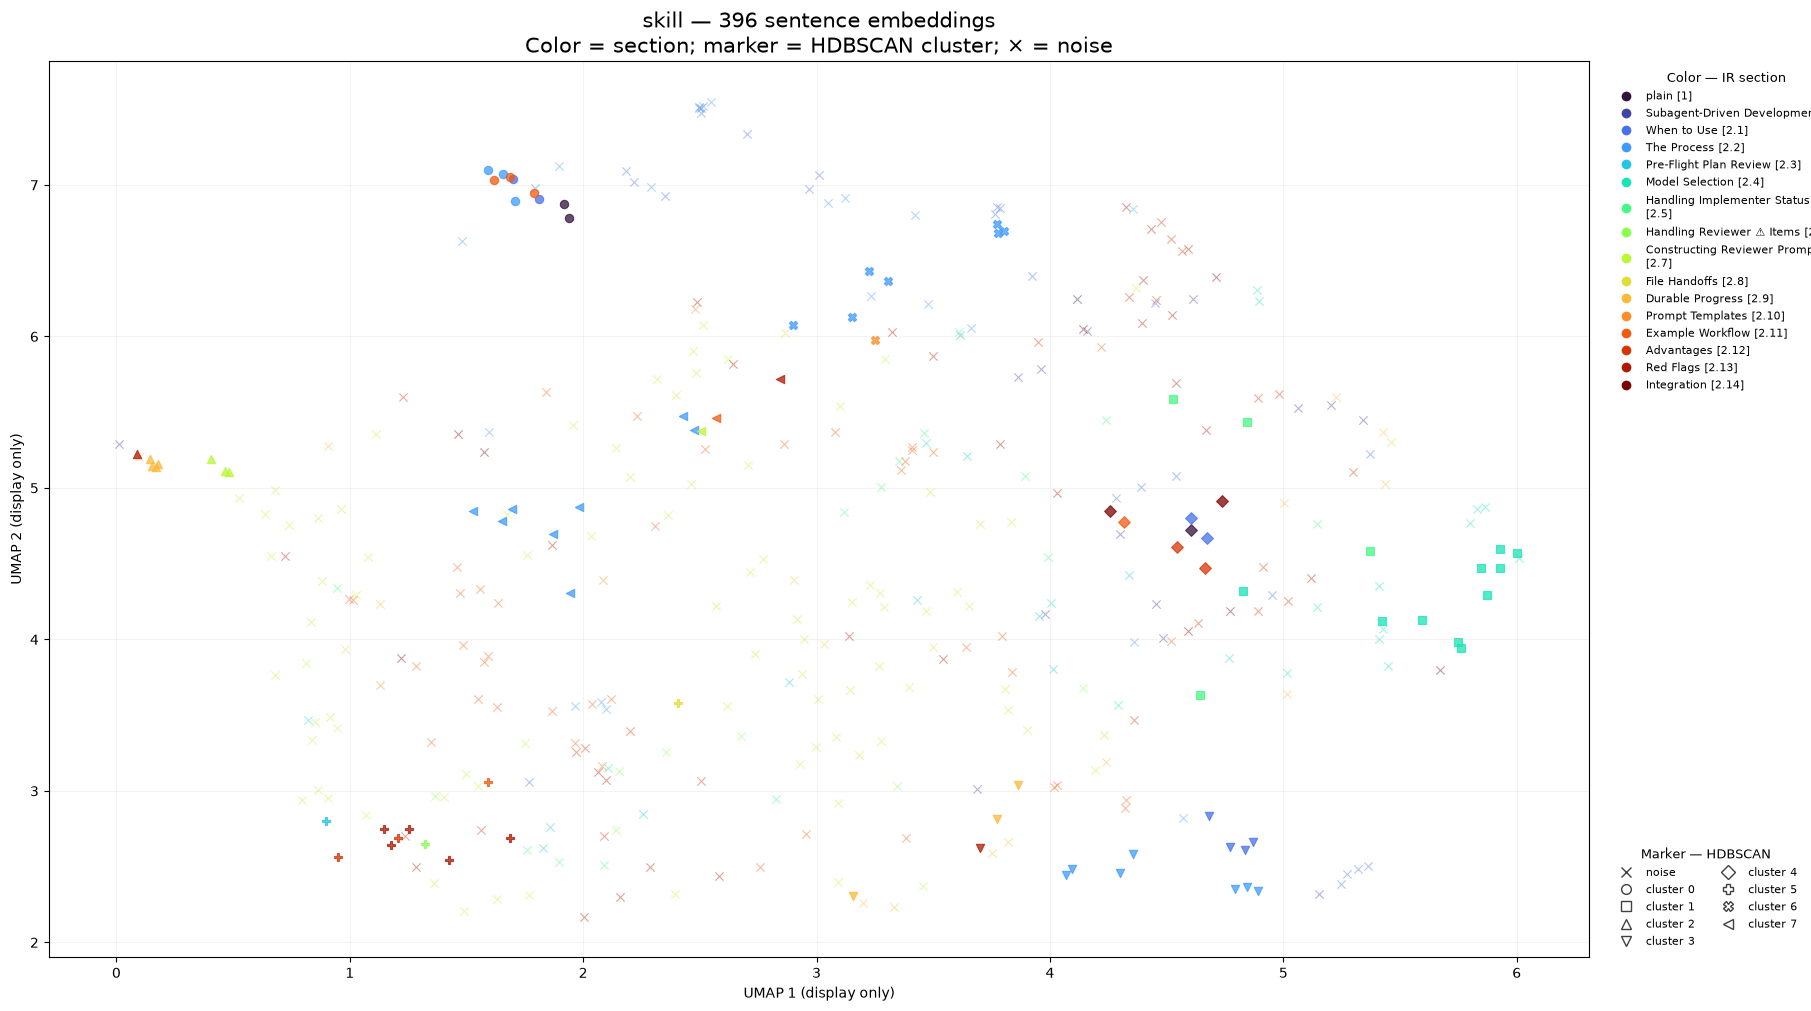

wrote notebooks/outputs/babilong_qa1_42_section_embedding_clusters.png


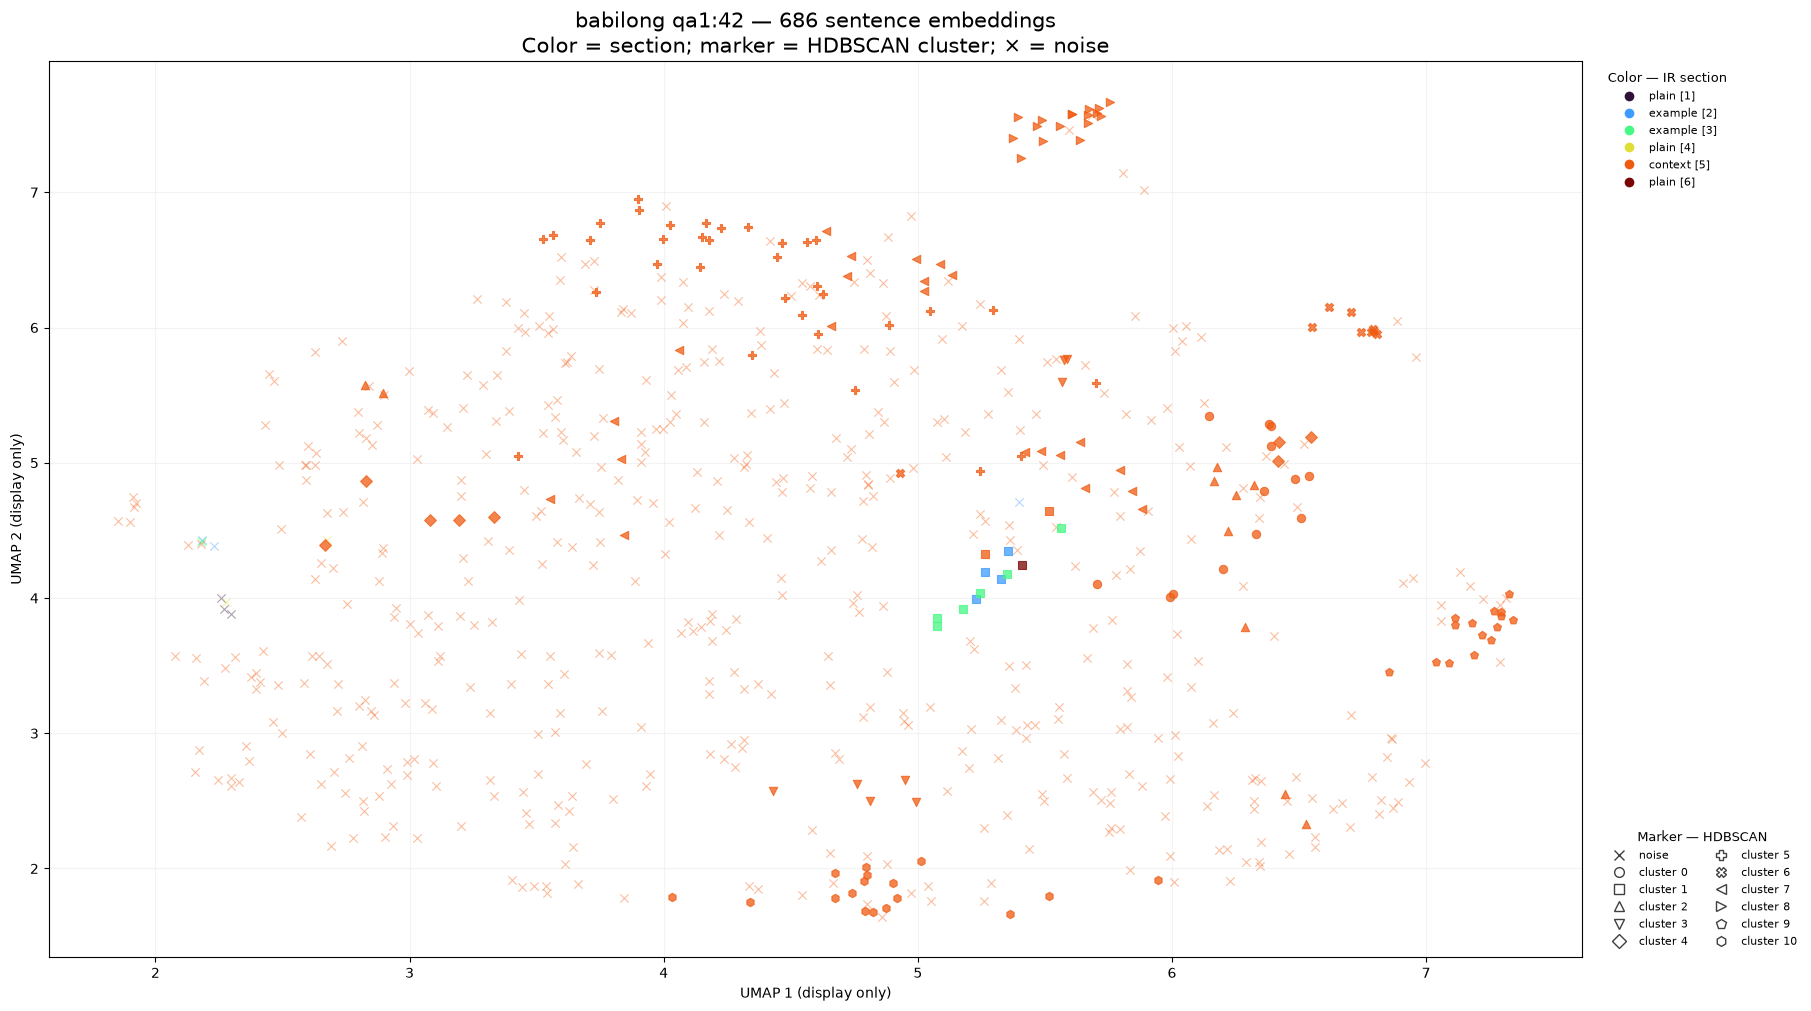

In [9]:
CLUSTER_MARKERS = ("o", "s", "^", "v", "D", "P", "X", "<", ">", "p", "h", "H", "8", "d", "*")


def plot_analysis(source: str, analysis: dict[str, object]) -> Path:
    source_rows = analysis["rows"]
    plot_space = analysis["plot_space"]
    cluster_labels = analysis["cluster_labels"]
    cluster_counts = analysis["cluster_counts"]
    section_names = list(dict.fromkeys(str(row["section"]) for row in source_rows))
    section_cmap = plt.colormaps["turbo"].resampled(len(section_names))
    section_colors = {name: section_cmap(index) for index, name in enumerate(section_names)}
    cluster_ids = sorted(label for label in cluster_counts if label != -1)
    cluster_markers = {label: CLUSTER_MARKERS[index % len(CLUSTER_MARKERS)] for index, label in enumerate(cluster_ids)}
    cluster_markers[-1] = "x"

    fig, axis = plt.subplots(figsize=(18, 10), constrained_layout=True)
    for label in sorted(cluster_counts):
        for section_name in section_names:
            mask = np.array(
                [
                    row["section"] == section_name and cluster_labels[index] == label
                    for index, row in enumerate(source_rows)
                ]
            )
            if not mask.any():
                continue
            axis.scatter(
                plot_space[mask, 0],
                plot_space[mask, 1],
                s=36,
                alpha=0.75 if label != -1 else 0.4,
                color=section_colors[section_name],
                marker=cluster_markers[label],
                linewidths=0.8,
            )

    section_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=section_colors[name],
            markeredgecolor="none",
            markersize=7,
            label=textwrap.fill(name.split(" / ", 1)[-1], width=32),
        )
        for name in section_names
    ]
    cluster_handles = [
        Line2D(
            [0],
            [0],
            marker=cluster_markers[label],
            color="0.25",
            markerfacecolor="white",
            markersize=7,
            linestyle="none",
            label="noise" if label == -1 else f"cluster {label}",
        )
        for label in sorted(cluster_counts)
    ]
    section_legend = axis.legend(
        handles=section_handles,
        title="Color — IR section",
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        fontsize=8,
        title_fontsize=9,
        frameon=False,
    )
    axis.add_artist(section_legend)
    axis.legend(
        handles=cluster_handles,
        title="Marker — HDBSCAN",
        loc="lower left",
        bbox_to_anchor=(1.01, 0.0),
        fontsize=8,
        title_fontsize=9,
        frameon=False,
        ncol=2,
    )
    axis.set_title(
        f"{source} — {len(source_rows):,} sentence embeddings\nColor = section; marker = HDBSCAN cluster; × = noise",
        fontsize=15,
    )
    axis.set_xlabel("UMAP 1 (display only)")
    axis.set_ylabel("UMAP 2 (display only)")
    axis.grid(alpha=0.15)

    slug = source.lower().replace(" ", "_").replace(":", "_")
    output_path = REPO_ROOT / f"notebooks/outputs/{slug}_section_embedding_clusters.png"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"wrote {output_path.relative_to(REPO_ROOT)}")
    plt.show()
    return output_path


output_paths = [plot_analysis(source, analyses[source]) for source in inputs]